# [MAIN QUEST 01] Space Titanic

## 프로젝트 개요

본 프로젝트는 Kaggle의 **Spaceship Titanic** 데이터를 활용하여 승객의 `Transported` 여부를 예측하는 분류 문제이다.  
데이터 탐색(EDA), 시각화, 전처리, 피처 엔지니어링, 모델 학습, 결과 분석을 진행하고 최종적으로 `submission.csv` 파일을 생성하여 Kaggle에 제출하였다.

- 목표 변수: `Transported`
- 사용 모델: XGBoost Classifier
- 최고 Public Score: **0.80196**
- 목표 점수: **0.805 이상**


## 목차

1. 프로젝트 개요
2. 데이터 불러오기 및 기본 확인
3. 데이터 탐색 및 시각화
4. 데이터 전처리 및 피처 엔지니어링
5. 모델 학습 및 성능 확인
6. 결과 분석 및 인사이트
7. Summary
8. 회고
9. Reference


In [1]:
# 데이터 분석용 라이브러리
import pandas as pd

# 수치 계산용 라이브러리
import numpy as np

# 그래프 그리기
import matplotlib.pyplot as plt

# 예쁜 그래프 그리기
import seaborn as sns

# 머신러닝 모델
from sklearn.ensemble import ExtraTreesClassifier

# 학습용 데이터와 검증용 데이터 분리
from sklearn.model_selection import train_test_split

# 모델 성능 측정
from sklearn.metrics import accuracy_score

## 1. 데이터 불러오기 및 기본 확인

학습 데이터(`train.csv`), 테스트 데이터(`test.csv`), 제출 양식(`sample_submission.csv`)을 불러온다.  
데이터의 크기와 컬럼 정보를 확인하여 어떤 변수들이 존재하는지 파악한다.


In [2]:
# 학습 데이터
train = pd.read_csv("train.csv")

# 예측할 데이터
test = pd.read_csv("test.csv")

# 제출 양식
submission = pd.read_csv("sample_submission.csv")

# 데이터 확인
display(train.head())
display(test.head())

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [3]:
# 행과 열 개수 확인
print(train.shape)

# 데이터 타입 확인
train.info()

(8693, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [4]:
# 각 컬럼에 비어있는 값이 몇 개인지 확인
print(train.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


## 2. 데이터 탐색 및 시각화

`Transported`, `CryoSleep`, `Age`, `HomePlanet` 변수를 시각화하여 목표 변수와 어떤 관련성이 있는지 확인하였다.  
시각화 결과를 바탕으로 모델에 활용할 주요 변수를 판단하였다.


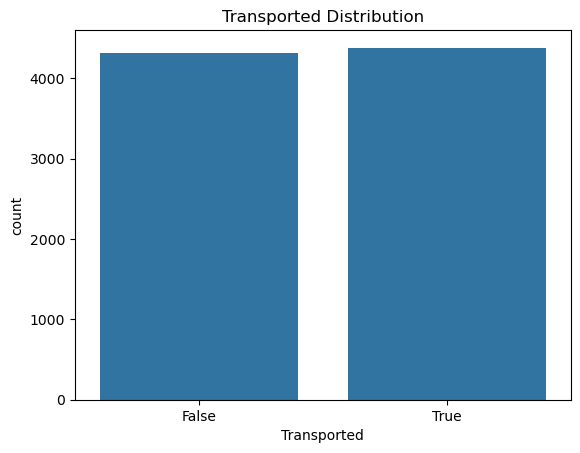

In [5]:
# True / False 개수 시각화

sns.countplot(x='Transported',data=train)

plt.title("Transported Distribution")

plt.show()

### Transported 분포 분석

Transported 값은 True와 False가 비교적 균형 있게 분포되어 있다.  
따라서 심각한 데이터 불균형 문제는 크지 않다고 판단하였다.

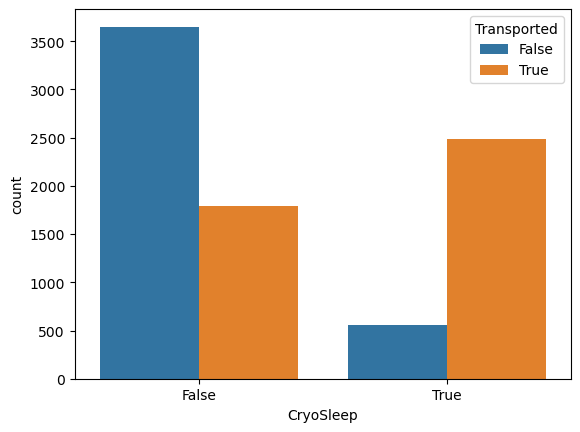

In [6]:
# CryoSleep 여부에 따라
# Transported 결과가 달라지는지 확인

sns.countplot(x='CryoSleep',hue='Transported',data=train)

plt.show()

### CryoSleep 분석

CryoSleep 상태인 승객은 Transported 비율이 높게 나타났다.  
따라서 CryoSleep은 Transported 여부 예측에 중요한 변수라고 판단하였다.

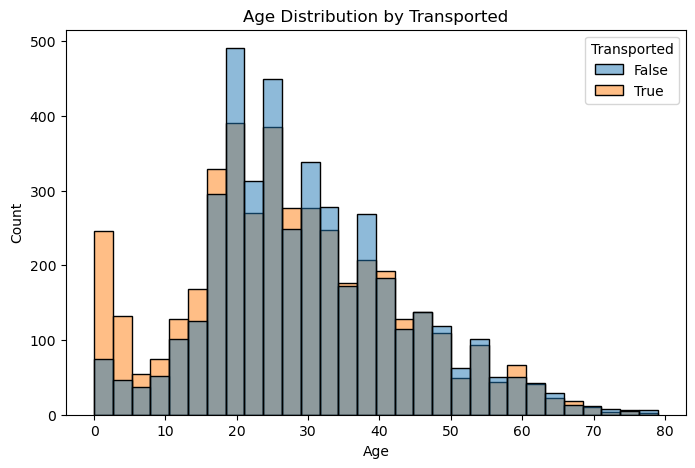

In [7]:
# 나이에 따른 Transported 분포 확인

plt.figure(figsize=(8,5))

sns.histplot(data=train,x='Age',hue='Transported',bins=30)

plt.title("Age Distribution by Transported")

plt.show()

### Age 분석

Age 분포를 확인한 결과 어린 승객의 Transported 비율이 상대적으로 높게 나타났다.  
따라서 나이 역시 예측에 활용 가능한 변수라고 판단하였다.

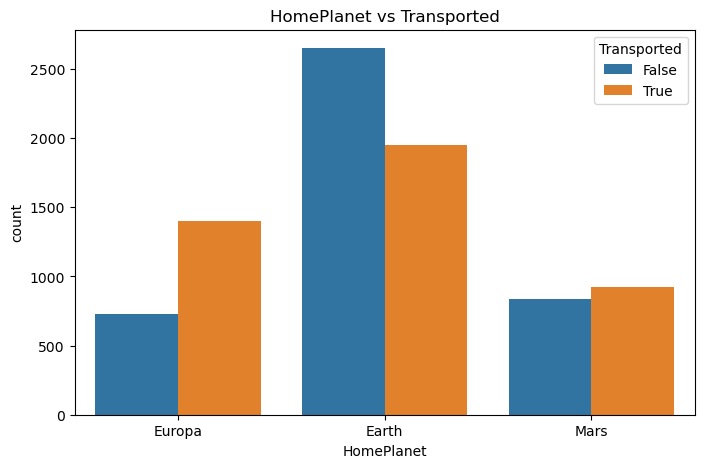

In [8]:
# HomePlanet별 Transported 결과 확인

plt.figure(figsize=(8,5))

sns.countplot(x='HomePlanet',hue='Transported',data=train)

plt.title("HomePlanet vs Transported")

plt.show()

### HomePlanet 분석

HomePlanet과 Transported의 관계를 시각화한 결과, Europa 출신 승객의 Transported 비율이 상대적으로 높게 나타났다.

반면 Earth 출신 승객은 Transported 비율이 상대적으로 낮게 나타났다.

이를 통해 출신 행성 정보가 Transported 여부를 예측하는 데 의미 있는 변수라고 판단하였다.

## 3. 데이터 전처리 및 피처 엔지니어링

모델 학습을 위해 정답 데이터(`Transported`)를 분리하고, train/test 데이터를 합쳐 동일한 방식으로 전처리하였다.

### 전처리 논리적 근거

- `PassengerId`에서 그룹 정보를 추출하여 함께 탑승한 승객 규모를 반영하였다.
- `Cabin`은 `Deck`, `CabinNum`, `Side`로 분리하여 객실 위치 정보를 세분화하였다.
- 선내 소비 금액 컬럼은 결측치를 0으로 처리하고, 총 소비 금액(`TotalSpend`)과 소비 여부(`NoSpend`)를 생성하였다.
- 범주형 변수는 결측치를 최빈값으로 대체한 뒤 One-Hot Encoding을 적용하였다.


In [9]:
# 우리가 맞춰야 하는 정답

y = train['Transported']

# 학습 데이터에서 정답 제거
train_data = train.drop('Transported',axis=1)

# test 복사
test_data = test.copy()

In [10]:
# train과 test를 합쳐서
# 같은 방식으로 전처리하기

full = pd.concat([train_data, test_data],axis=0)

In [11]:
# 그룹번호 추출
full['Group'] = (full['PassengerId'].str.split('_').str[0].astype(int))

In [12]:
# 같은 그룹에 몇 명 있는지 계산
full['GroupSize'] = (full.groupby('Group')['PassengerId'].transform('count'))


In [13]:
# Cabin 예시
# B/123/P

full[['Deck','CabinNum','Side']] = (full['Cabin'].str.split('/', expand=True))

In [14]:
#숫자형 변환
full['CabinNum'] = pd.to_numeric(full['CabinNum'],errors='coerce')

In [15]:
# CabinNum 결측치 처리
full['CabinNum'] = full['CabinNum'].fillna(full['CabinNum'].median())

In [16]:
#소비 컬럼 생성
expense_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

In [17]:
#결측치 0처리
for col in expense_cols:

    full[col] = full[col].fillna(0)

In [18]:
#총 소비금액 생성
full['TotalSpend'] = (full[expense_cols].sum(axis=1))

In [19]:
#소비 여부 생성
full['NoSpend'] = (full['TotalSpend'] == 0)

In [20]:
#나이 결측치 처리
#full['Age'] = full['Age'].fillna(full['Age'].median())

In [21]:
full['AgeGroup'] = pd.cut(full['Age'],
    bins=[-1, 12, 18, 30, 50, 100],
    labels=['Child', 'Teen', 'Young', 'Adult', 'Senior']
)

In [22]:
#범주형 결측치 처리

cat_cols = ['HomePlanet','CryoSleep','Destination','VIP','Deck','Side','AgeGroup']

for col in cat_cols:
    full[col] = full[col].fillna(full[col].mode()[0])

/tmp/ipykernel_3969/3981667889.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full[col] = full[col].fillna(full[col].mode()[0])


In [23]:
#필요없는 컬럼 제거
full = full.drop(['PassengerId','Name','Cabin'],axis=1)

In [24]:
#원-핫 인코딩
full = pd.get_dummies(full,drop_first=True)

In [25]:
#train.test 분리
X = full.iloc[:len(train)]

X_test = full.iloc[len(train):]

In [26]:
#데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## 4. 모델 학습 및 제출 파일 생성

기본 모델보다 성능을 높이기 위해 XGBoost 모델을 사용하였다.  
검증 데이터에서 여러 threshold를 실험하여 가장 높은 정확도를 보이는 기준값을 찾고, 이후 전체 학습 데이터로 다시 학습하여 최종 제출 파일을 생성하였다.


In [27]:
# XGBoost 모델 사용을 위한 라이브러리 불러오기
from xgboost import XGBClassifier

# 학습용 데이터와 검증용 데이터를 나누기 위한 함수
from sklearn.model_selection import train_test_split

# 모델 성능 평가를 위한 정확도 함수
from sklearn.metrics import accuracy_score

# threshold 값을 여러 개 만들기 위해 numpy 사용
import numpy as np


# --------------------------------------------------
# 1. 학습 데이터와 검증 데이터 분리
# --------------------------------------------------
# X : 입력 데이터
# y : 정답 데이터(Transported)
# stratify=y : Transported의 True/False 비율을 train/valid에 비슷하게 유지
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


# --------------------------------------------------
# 2. XGBoost 모델 생성
# --------------------------------------------------
model = XGBClassifier(
    n_estimators=500,# n_estimators : 생성할 트리 개수
    learning_rate=0.03,# learning_rate : 학습률
    max_depth=4,# max_depth : 트리의 최대 깊이
    subsample=0.8,# subsample : 학습에 사용할 행 샘플 비율
    colsample_bytree=0.8,# colsample_bytree : 학습에 사용할 컬럼 샘플 비율
    eval_metric='logloss',
    random_state=42
)


# --------------------------------------------------
# 3. 검증용 데이터로 모델 학습
# --------------------------------------------------
model.fit(X_train, y_train)


# --------------------------------------------------
# 4. 검증 데이터 예측 확률 계산
# --------------------------------------------------
# predict_proba()는 False/True일 확률을 반환한다.
# [:, 1]은 Transported=True일 확률만 가져온다는 뜻이다.
valid_proba = model.predict_proba(X_valid)[:, 1]


# --------------------------------------------------
# 5. 최적 threshold 찾기
# --------------------------------------------------
# 기본 threshold는 0.5이지만, 0.40~0.60 사이를 탐색하여
# 검증 정확도가 가장 높은 threshold를 찾는다.
best_acc = 0
best_threshold = 0.5

for threshold in np.arange(0.40, 0.61, 0.01):
    valid_pred = valid_proba > threshold
    acc = accuracy_score(y_valid, valid_pred)

    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

print("검증 최고 정확도:", best_acc)
print("최적 threshold:", best_threshold)


# --------------------------------------------------
# 6. 전체 학습 데이터로 최종 모델 재학습
# --------------------------------------------------
# 최종 제출 전에는 train/valid로 나누지 않고 전체 train 데이터를 사용한다.
model.fit(X, y)


# --------------------------------------------------
# 7. test 데이터 예측
# --------------------------------------------------
test_proba = model.predict_proba(X_test)[:, 1]
pred = test_proba > best_threshold


# --------------------------------------------------
# 8. 제출 파일 생성
# --------------------------------------------------
submission['Transported'] = pred

submission.to_csv('submission.csv',index=False)

print("XGBoost submission.csv 생성 완료!")
display(submission.head())


검증 최고 정확도: 0.8154111558366878
최적 threshold: 0.5800000000000002
XGBoost submission.csv 생성 완료!


,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


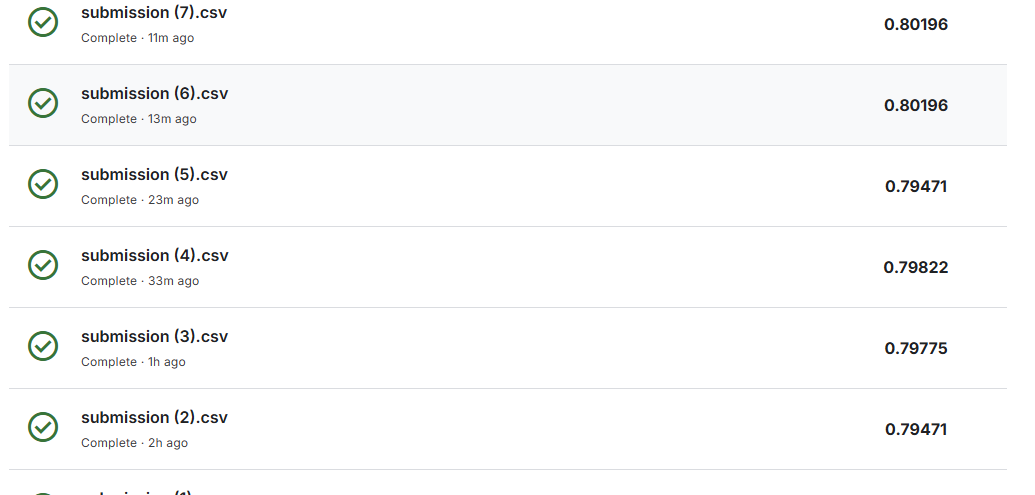

## 5. 모델 학습 결과 및 인사이트

XGBoost 모델을 적용한 결과 기존 기본 제출 파일보다 Public Score가 크게 향상되었다.

- 기본 제출 점수: 약 **0.49310**
- ExtraTrees 기반 제출 점수: 약 **0.79869**
- XGBoost 기반 최고 제출 점수: **0.80196**

목표 점수인 0.805 이상에는 조금 부족했지만, 전처리와 모델 변경을 통해 성능이 크게 개선되었다.  
특히 `CryoSleep`, `HomePlanet`, `Cabin`에서 분리한 객실 위치 정보, 소비 금액 관련 변수가 Transported 예측에 중요한 역할을 한 것으로 판단된다.


## 6. Summary

본 프로젝트에서는 Space Titanic 데이터를 활용하여 승객의 `Transported` 여부를 예측하였다.  
EDA를 통해 `CryoSleep`, `HomePlanet`, `Age` 등의 변수가 목표 변수와 관련이 있음을 확인하였다.  
전처리 과정에서는 `Cabin` 분리, `GroupSize` 생성, `TotalSpend` 및 `NoSpend` 생성, 범주형 변수 인코딩을 수행하였다.  
최종적으로 XGBoost 모델을 사용하여 Public Score **0.80196**을 달성하였다.


# 회고

이번 프로젝트에서는 단순히 모델을 학습하는 것뿐만 아니라, 데이터 탐색부터 전처리, 피처 엔지니어링, 모델 튜닝, 제출 파일 생성까지 전체 머신러닝 프로젝트 흐름을 경험하였다.

처음에는 기본 제출 파일을 제출하여 낮은 점수를 얻었지만, 결측치 처리와 `Cabin`, `PassengerId`, 소비 금액 정보를 활용한 피처 엔지니어링을 적용하면서 성능이 크게 향상되었다. 이후 ExtraTrees와 XGBoost 모델을 비교하며 모델 선택이 성능에 영향을 준다는 것을 확인하였다.

최종 Public Score는 목표 점수인 0.805에는 조금 부족한 **0.80196**이었지만, 여러 번의 실험을 통해 데이터 전처리와 모델 튜닝의 중요성을 배울 수 있었다. 향후에는 CatBoost, LightGBM, 더 정교한 결측치 처리 및 앙상블 기법을 적용하여 성능을 더 높여보고 싶다.


## 7. Reference

- Kaggle Spaceship Titanic Competition  
  https://www.kaggle.com/competitions/spaceship-titanic
- XGBoost Documentation  
  https://xgboost.readthedocs.io/
- Scikit-learn Documentation  
  https://scikit-learn.org/stable/
